In [2]:
import pandas as pd

df = pd.read_csv("../Datasets/Housing.csv")

print("Shape:", df.shape)

df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
df = pd.get_dummies(df, drop_first=True)

print(df.shape)
df.head()

(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [5]:
X = df.drop("price", axis=1)

y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (436, 13)
Test Shape: (109, 13)


In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 970043.4039201637
R2 Score: 0.6529242642153184


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MAE: 1195266.0550458715
Decision Tree R2: 0.4771459275854347


In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MAE: 1195266.0550458715
Decision Tree R2: 0.4771459275854347


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 1021546.0353211008
Random Forest R2: 0.611918531405699


In [12]:
import matplotlot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2_scores = [0.653, 0.477, 0.612]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()


ModuleNotFoundError: No module named 'matplotlot'

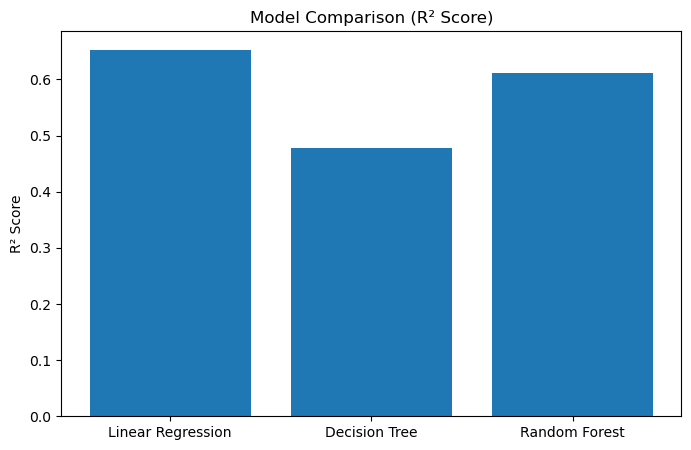

In [13]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2_scores = [0.653, 0.477, 0.612]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

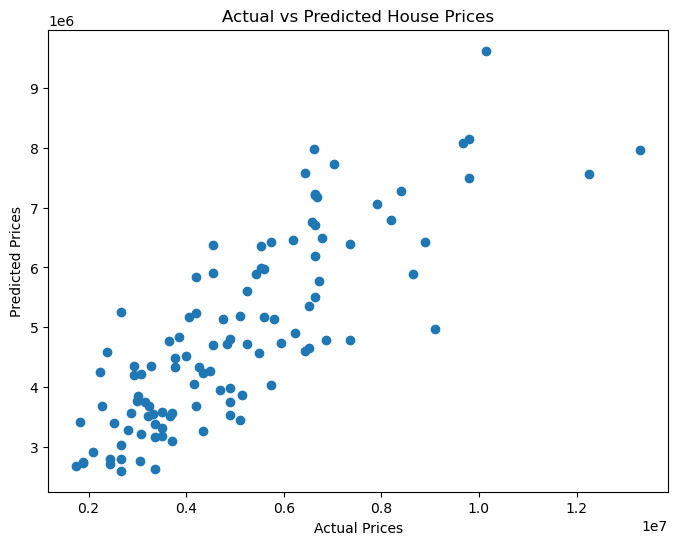

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


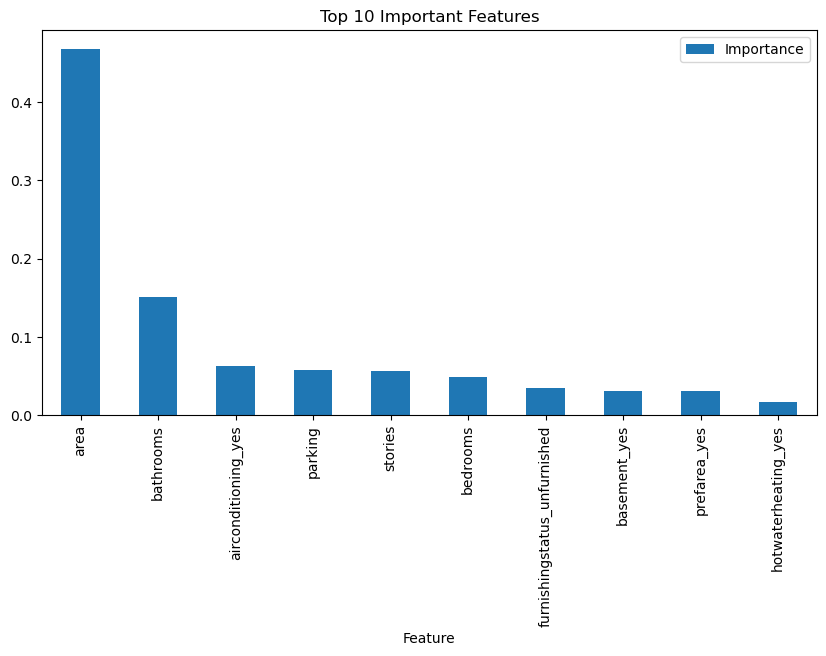

In [16]:
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()